In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/Social_Network_Ads csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [5]:
df.drop('User ID',axis=1,inplace=True)

In [6]:
df.drop('Gender',axis=1,inplace=True)

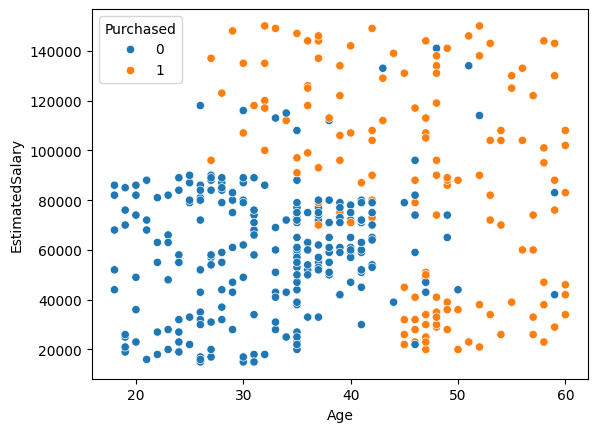

In [45]:
sns.scatterplot(x='Age',y='EstimatedSalary',data=df,hue='Purchased')
plt.show()

In [7]:
x=df.iloc[:,:-1]
y=df['Purchased']

In [8]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [9]:
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [10]:
from sklearn.preprocessing import StandardScaler



In [11]:
st=StandardScaler()
st.fit(x)
x=pd.DataFrame(st.transform(x),columns=x.columns)

In [12]:
x

,Age,EstimatedSalary
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751
...,...,...
395,0.797057,-0.844019
396,1.274623,-1.372587
397,1.179110,-1.460681
398,-0.158074,-1.078938


In [13]:
from sklearn.model_selection import train_test_split


In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
x_train

,Age,EstimatedSalary
3,-1.017692,-0.374182
18,0.797057,-1.225763
202,0.128465,1.886912
250,0.606031,-0.902749
274,1.847701,-1.284492
...,...,...
71,-1.304232,-1.255127
106,-1.113206,-1.020209
270,0.510518,1.857547
348,0.128465,0.213115


In [16]:
from sklearn.tree import DecisionTreeClassifier

In [24]:
from mlxtend.plotting import plot_decision_regions

In [40]:
dc=DecisionTreeClassifier(max_depth=3)
dc.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [41]:
dc.score(x_test,y_test)*100

91.25

In [42]:
dc.score(x_train,y_train)*100

91.875

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


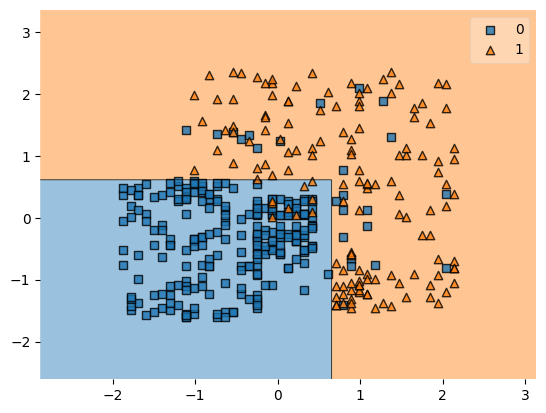

In [43]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dc)
plt.show()

In [22]:
dc1=DecisionTreeClassifier(criterion='entropy')
dc1.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [29]:
dc1.score(x_test,y_test)

0.8375

In [23]:
dc1.score(x_train,y_train)

0.996875

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


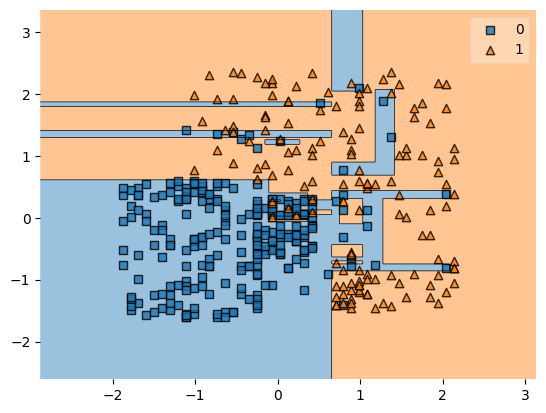

In [27]:
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=dc1)
plt.show()

In [19]:
dc.predict([[19,19000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [20]:
from sklearn.tree import plot_tree

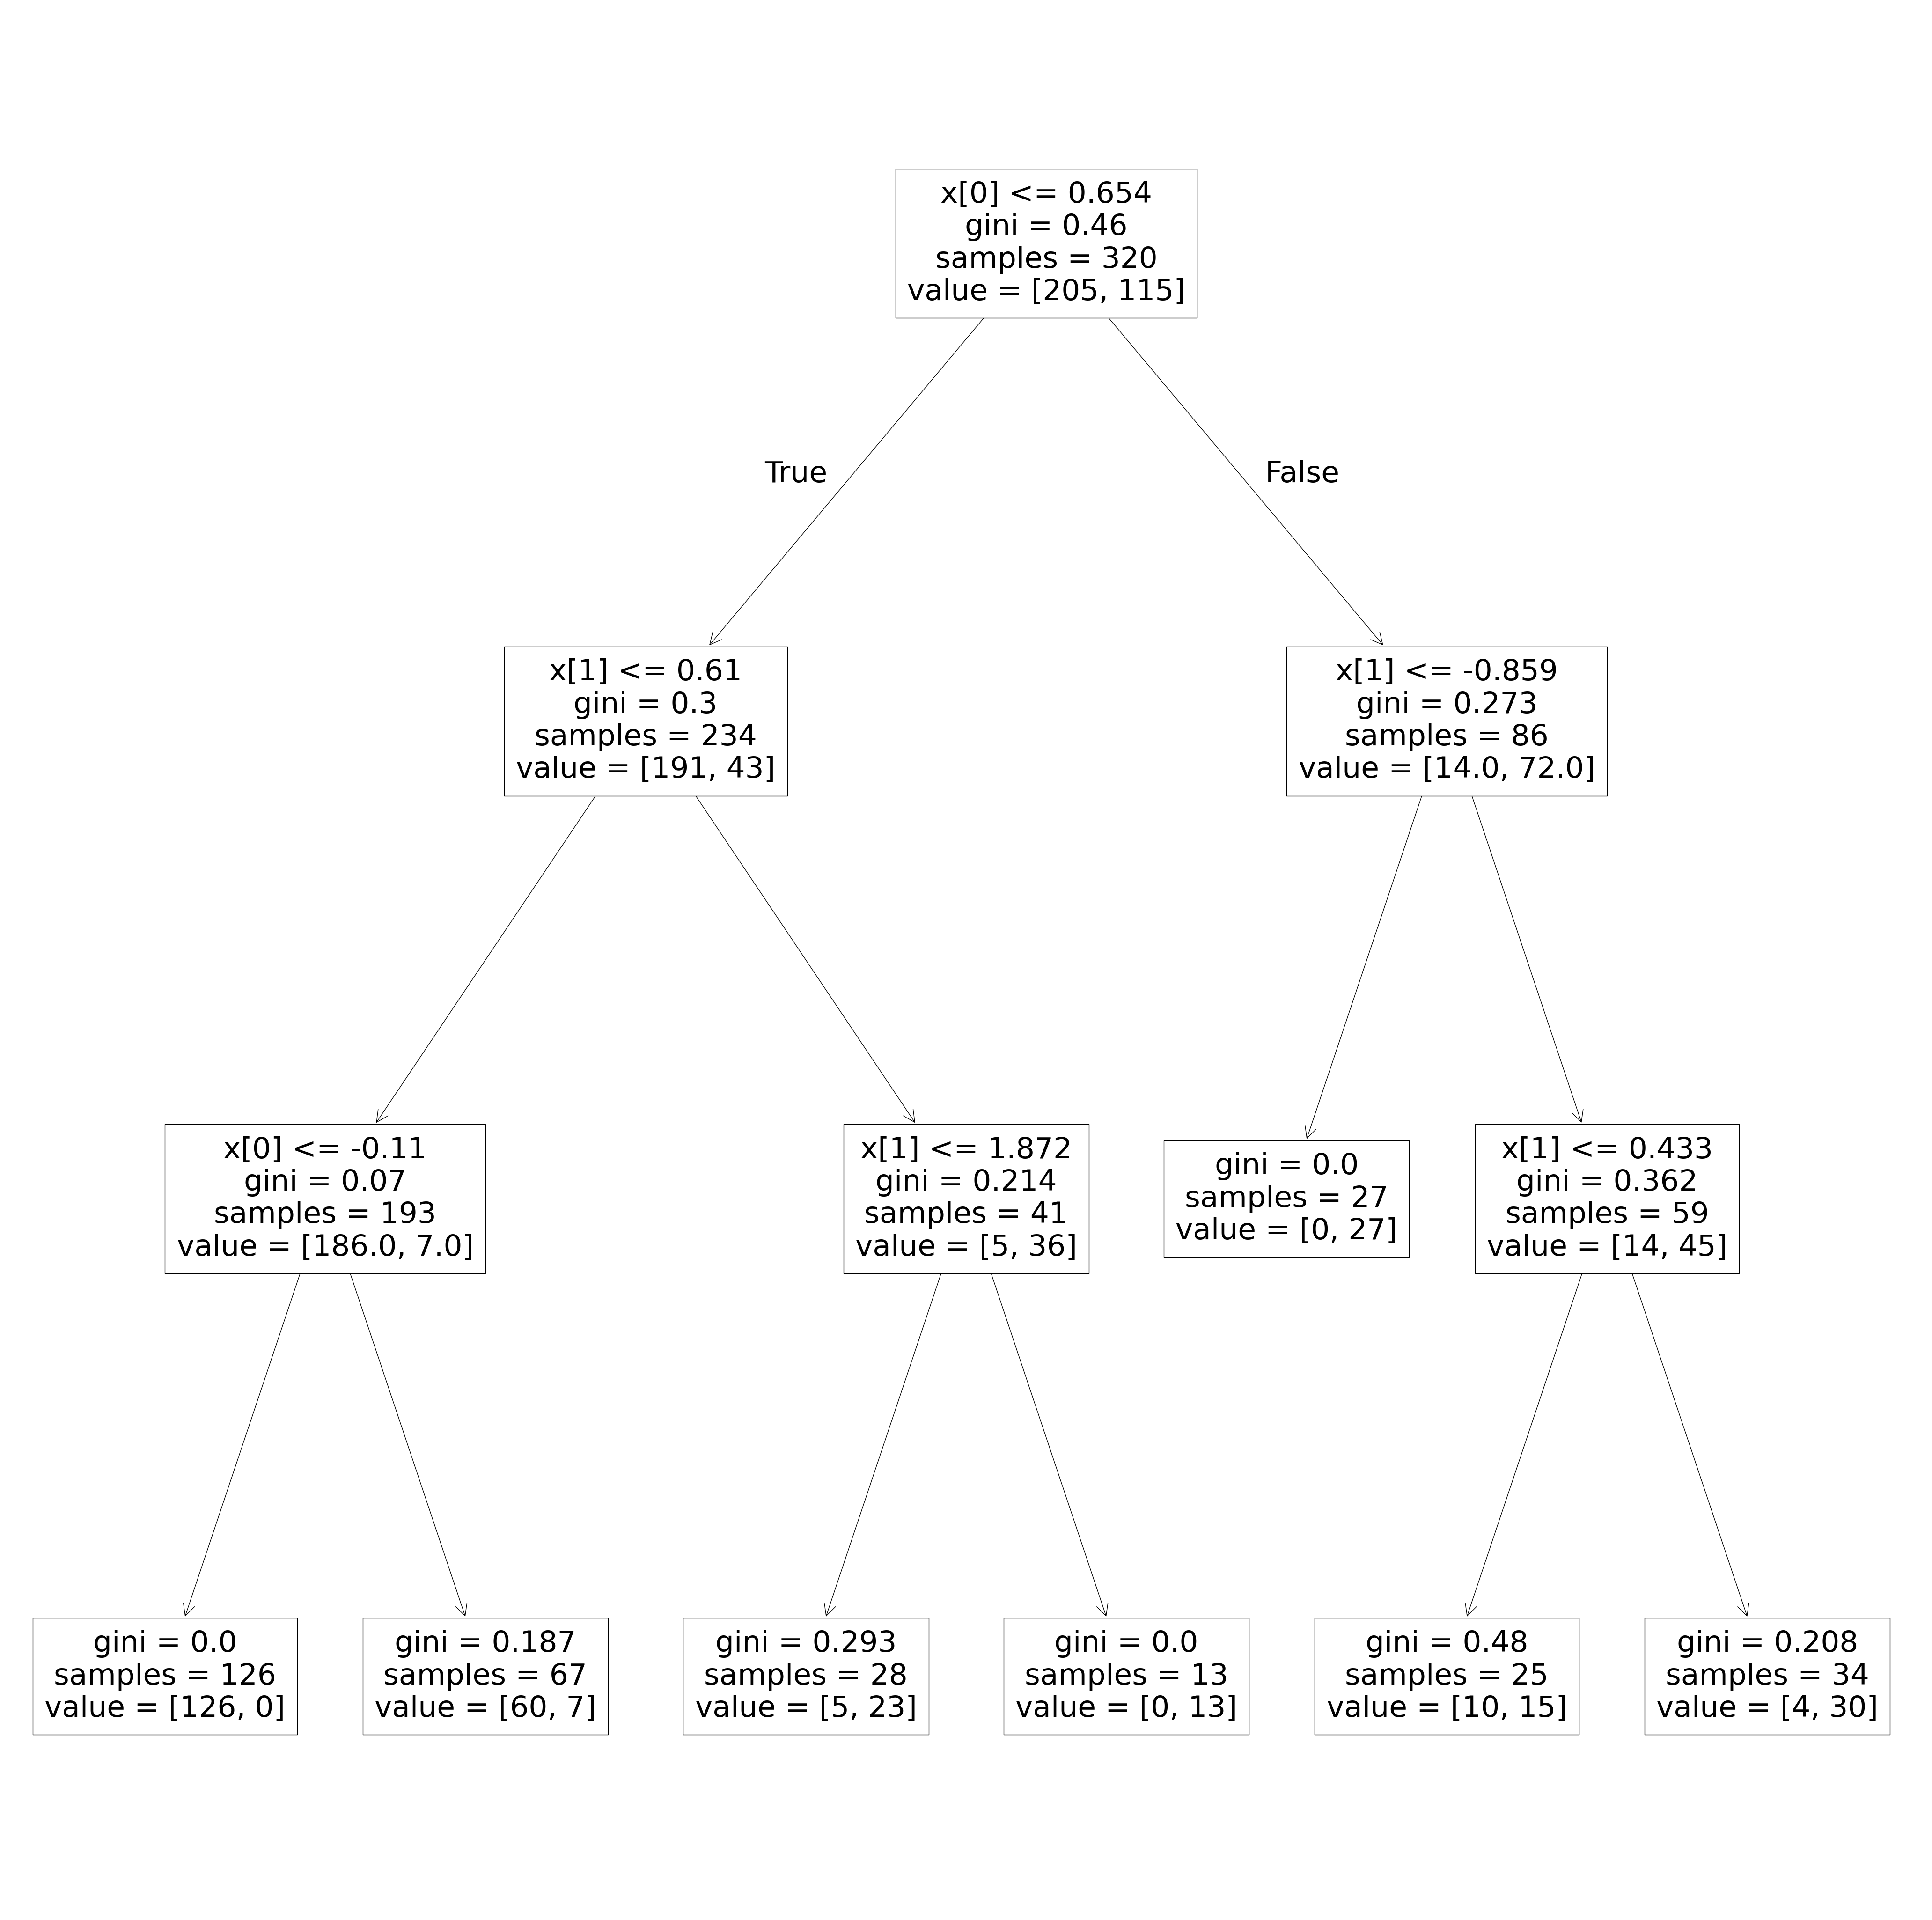

In [44]:
plt.figure(figsize=(53,53))
plot_tree(dc)
plt.savefig('tree.jpg')
plt.show()

In [39]:
for i in range(1,20):
  dt2=DecisionTreeClassifier(max_depth=i)
  dt2.fit(x_train,y_train)
  print((dt2.score(x_train,y_train),dt2.score(x_test,y_test),i))


(0.821875, 0.9, 1)
(0.91875, 0.9125, 2)
(0.91875, 0.9125, 3)
(0.93125, 0.9125, 4)
(0.934375, 0.9, 5)
(0.95, 0.8625, 6)
(0.96875, 0.85, 7)
(0.971875, 0.85, 8)
(0.98125, 0.85, 9)
(0.984375, 0.85, 10)
(0.990625, 0.8375, 11)
(0.99375, 0.8375, 12)
(0.99375, 0.8375, 13)
(0.996875, 0.8375, 14)
(0.996875, 0.8375, 15)
(0.996875, 0.8375, 16)
(0.996875, 0.8375, 17)
(0.996875, 0.8375, 18)
(0.996875, 0.8375, 19)
